<a href="https://colab.research.google.com/github/sufiyatabasum455-sss/PRODIGY_GA_04/blob/main/Task_04_%E2%80%93_Image_to_Image_Translation_with_cGANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import tensorflow as tf
import os

print("Downloading Pix2Pix Facades dataset...")

url = "https://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz"

path = tf.keras.utils.get_file(
    "facades.tar.gz",
    origin=url,
    extract=True
)

print("Dataset downloaded successfully!")
print("Dataset path:", path)

30168306/30168306 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset downloaded successfully!
Dataset path: /root/.keras/datasets/facades_extracted


In [6]:
import os

base_path = os.path.expanduser("~/.keras/datasets")

print("Files and folders in the dataset directory:")
print(os.listdir(base_path))

Files and folders in the dataset directory:
['facades.tar.gz', 'facades_extracted']


In [7]:
print(os.listdir(base_path))

['facades.tar.gz', 'facades_extracted']


In [8]:
import os

dataset_path = os.path.join(base_path, "facades_extracted")

print("Inside facades_extracted:")
print(os.listdir(dataset_path))

Inside facades_extracted:
['facades']


In [9]:
facades_path = os.path.join(dataset_path, "facades")

print("Inside facades:")
print(os.listdir(facades_path))

Inside facades:
['val', 'train', 'test']


Image file: 358.jpg
Image size: (512, 256)


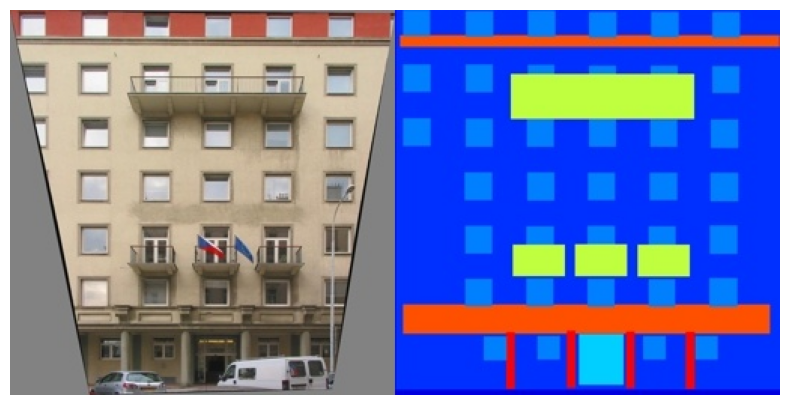

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_path = os.path.join(facades_path, "train")

# Get the first image
image_file = os.listdir(train_path)[0]
image_path = os.path.join(train_path, image_file)

image = Image.open(image_path)

print("Image file:", image_file)
print("Image size:", image.size)

plt.figure(figsize=(10, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

In [11]:
import tensorflow as tf

IMG_WIDTH = 128
IMG_HEIGHT = 128

def load_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    # Split the combined image into input and target
    width = tf.shape(image)[1]
    input_image = image[:, :width // 2, :]
    target_image = image[:, width // 2:, :]

    # Resize
    input_image = tf.image.resize(
        input_image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    target_image = tf.image.resize(
        target_image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert pixels from [0,255] to [-1,1]
    input_image = (input_image / 127.5) - 1
    target_image = (target_image / 127.5) - 1

    return input_image, target_image


print("Image preprocessing function created successfully!")

Image preprocessing function created successfully!


In [12]:
train_files = [
    os.path.join(train_path, file)
    for file in os.listdir(train_path)
    if file.endswith(".jpg")
]

print("Number of training images:", len(train_files))

train_dataset = tf.data.Dataset.from_tensor_slices(train_files)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(400)
train_dataset = train_dataset.batch(1)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Training dataset prepared successfully!")

Number of training images: 400
Training dataset prepared successfully!


In [13]:
from tensorflow.keras import layers

def build_generator():
    inputs = layers.Input(shape=[128, 128, 3])

    # Encoder
    e1 = layers.Conv2D(64, 4, strides=2, padding="same")(inputs)
    e1 = layers.LeakyReLU()(e1)

    e2 = layers.Conv2D(128, 4, strides=2, padding="same")(e1)
    e2 = layers.BatchNormalization()(e2)
    e2 = layers.LeakyReLU()(e2)

    e3 = layers.Conv2D(256, 4, strides=2, padding="same")(e2)
    e3 = layers.BatchNormalization()(e3)
    e3 = layers.LeakyReLU()(e3)

    # Decoder
    d1 = layers.Conv2DTranspose(128, 4, strides=2, padding="same")(e3)
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.ReLU()(d1)

    d2 = layers.Conv2DTranspose(64, 4, strides=2, padding="same")(d1)
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.ReLU()(d2)

    outputs = layers.Conv2DTranspose(
        3, 4, strides=2, padding="same", activation="tanh"
    )(d2)

    return tf.keras.Model(inputs, outputs)


generator = build_generator()

print("Generator created successfully!")
generator.summary()

Generator created successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 3)    │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,811 (5.03 MB)

 Trainable params: 1,318,659 (5.03 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [14]:
def build_discriminator():
    input_image = layers.Input(shape=[128, 128, 3])
    target_image = layers.Input(shape=[128, 128, 3])

    # Combine input and target images
    x = layers.Concatenate()([input_image, target_image])

    x = layers.Conv2D(64, 4, strides=2, padding="same")(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    outputs = layers.Conv2D(
        1, 4, padding="same"
    )(x)

    return tf.keras.Model(
        [input_image, target_image],
        outputs
    )


discriminator = build_discriminator()

print("Discriminator created successfully!")
discriminator.summary()

Discriminator created successfully!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 6)                │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      6,208 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    131,200 │ leaky_re_lu_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    524,544 │ leaky_re_lu_4[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16, 1) │      4,097 │ leaky_re_lu_5[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 667,585 (2.55 MB)

 Trainable params: 666,817 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)

In [15]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = loss_object(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = loss_object(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output, generated_image, target_image):
    adversarial_loss = loss_object(
        tf.ones_like(fake_output),
        fake_output
    )

    # L1 loss helps the generated image stay similar to the target
    l1_loss = tf.reduce_mean(
        tf.abs(target_image - generated_image)
    )

    return adversarial_loss + (100 * l1_loss)


print("cGAN loss functions created successfully!")

cGAN loss functions created successfully!


In [16]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5
)

print("Optimizers created successfully!")

Optimizers created successfully!


In [17]:
@tf.function
def train_step(input_image, target_image):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_image = generator(input_image, training=True)

        real_output = discriminator(
            [input_image, target_image],
            training=True
        )

        fake_output = discriminator(
            [input_image, generated_image],
            training=True
        )

        gen_loss = generator_loss(
            fake_output,
            generated_image,
            target_image
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    generator_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    discriminator_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            generator_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            discriminator_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


print("Training step created successfully!")

Training step created successfully!


In [18]:
EPOCHS = 5

print("Starting cGAN training...")
print("================================")

for epoch in range(EPOCHS):

    total_gen_loss = 0
    total_disc_loss = 0
    steps = 0

    for input_image, target_image in train_dataset:

        gen_loss, disc_loss = train_step(
            input_image,
            target_image
        )

        total_gen_loss += gen_loss
        total_disc_loss += disc_loss
        steps += 1

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Generator Loss: {total_gen_loss / steps:.4f} "
        f"- Discriminator Loss: {total_disc_loss / steps:.4f}"
    )

print("================================")
print("Training completed successfully!")

Starting cGAN training...
Epoch 1/5 - Generator Loss: 46.0984 - Discriminator Loss: 0.5164
Epoch 2/5 - Generator Loss: 41.9871 - Discriminator Loss: 0.4625
Epoch 3/5 - Generator Loss: 41.1807 - Discriminator Loss: 0.4907
Epoch 4/5 - Generator Loss: 40.3106 - Discriminator Loss: 0.4667
Epoch 5/5 - Generator Loss: 39.6490 - Discriminator Loss: 0.4728
Training completed successfully!


In [19]:
# Take one image from the test set

test_path = os.path.join(facades_path, "test")

test_files = [
    os.path.join(test_path, file)
    for file in os.listdir(test_path)
    if file.endswith(".jpg")
]

test_image_path = test_files[0]

input_image, target_image = load_image(test_image_path)

# Add batch dimension
input_batch = tf.expand_dims(input_image, axis=0)

# Generate translated image
generated_image = generator(
    input_batch,
    training=False
)[0]

print("Image translation completed!")

Image translation completed!


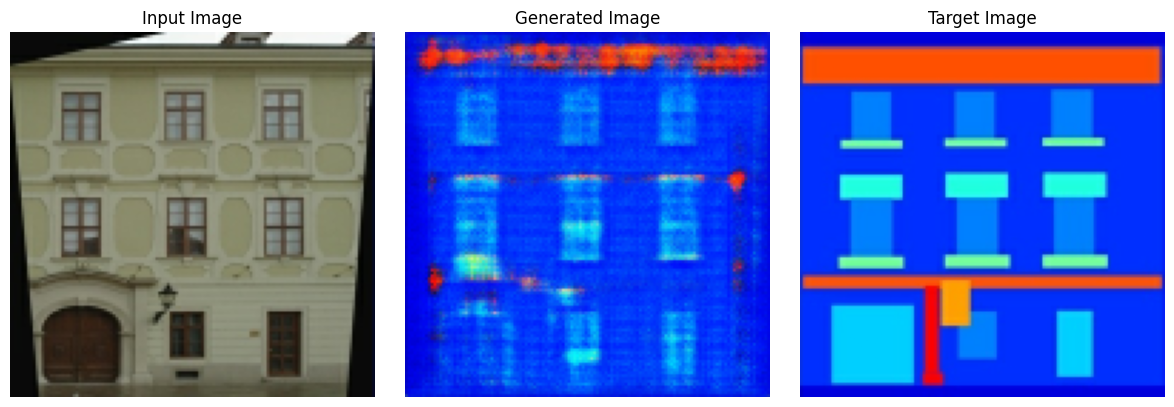

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow((input_image + 1) / 2)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Generated Image")
plt.imshow((generated_image + 1) / 2)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Target Image")
plt.imshow((target_image + 1) / 2)
plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
output_path = "translated_image.png"

# Convert pixels from [-1, 1] back to [0, 255]
output_image = ((generated_image + 1) * 127.5).numpy()
output_image = output_image.clip(0, 255).astype("uint8")

Image.fromarray(output_image).save(output_path)

print("Generated image saved successfully!")
print("File:", output_path)

Generated image saved successfully!
File: translated_image.png


In [22]:
from google.colab import files

files.download("translated_image.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>